<a href="https://colab.research.google.com/github/Dogyun-Kim57/AI_26/blob/main/AI%EA%B8%B0%EB%B0%98%EC%98%88%EC%B8%A1%EB%B0%8F%EB%B6%84%EC%84%9D(%EA%B9%80%EB%8F%84%EA%B7%A0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#MBC 마켓에서 이번엔 럭키백을 패션분야에 접목을 시키려고 한다.

# CCTV로 판매할 제품의 객체를 판단하는 AI 모델을 만드시오

# 1. 패션 MNIST 데이터 셋을 활용한다.
# 2. target은 10개의 항목으로 되어 있다.
# 3. 정답 : 0티셔츠, 1바지, 2스웨터, 3드레스, 4코트, 5샌달, 6셔츠, 7스니커즈, 8가방, 9앵클부츠

In [38]:
# < 데이터 전처리 >
import tensorflow as tf                          # 텐서플로 사용
import matplotlib.pyplot as plt                  # 그래프 기능 사용
import numpy as np                               # 검증 정확도 확인용


tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# experimental = 이 기능은 사용 가능하지만, 앞으로 바뀔 수도 있다.
# enable_op_determinism() = 항상 동일한 연산 순서로 계산해라!

from tensorflow import keras
from sklearn.model_selection import train_test_split

# 사용할 더미 데이터는 keras 패키지에서 제공하는 fashion_mnist를 활용
(train_input, train_target), (test_input, test_target) =\
     keras.datasets.fashion_mnist.load_data()

# 이미지 픽셀 값 ( 0 ~ 255 )을 0 ~ 1 범위로 정규화해서 일관성을 만들고, 학습을 안정적으로 만들기
train_scaled = train_input / 255.0

# 여기까지가 전처리 과정

In [17]:
# 훈련,검증,테스트 데이터 shape

# 훈련용, 검증용, 테스트용 데이터 나누기
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

print(" < 훈련 데이터 > ")
print(train_scaled.shape, train_target.shape)
print(" < 테스트 데이터 > ")
print(test_input.shape, test_target.shape)
print(" < 검증 데이터 > ")
print(val_scaled.shape, val_target.shape)

 < 훈련 데이터 > 
(48000, 28, 28) (48000,)
 < 테스트 데이터 > 
(10000, 28, 28) (10000,)
 < 검증 데이터 > 
(12000, 28, 28) (12000,)


In [53]:
# 모델용 객체 생성 메서드
def model_fn(a_layer=None):

    model = keras.Sequential()

    # 입력층
    model.add(keras.layers.Flatten(input_shape=(28,28)))

    # 은닉층
    model.add(keras.layers.Dense(100, activation='relu'))

    # 추가 레이어 (Dropout 등)
    if a_layer:
        model.add(a_layer)

    # 출력층
    model.add(keras.layers.Dense(10, activation='softmax'))

    return model

In [47]:
# 다중분류를 위한 컴파일 ( 최적화 전 )
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#             손실          다중분류                             정확도
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))



Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7765 - loss: 0.6441 - val_accuracy: 0.8238 - val_loss: 0.4704
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8586 - loss: 0.3949 - val_accuracy: 0.8631 - val_loss: 0.3754
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8735 - loss: 0.3547 - val_accuracy: 0.8692 - val_loss: 0.3580
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8820 - loss: 0.3334 - val_accuracy: 0.8809 - val_loss: 0.3307
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8894 - loss: 0.3173 - val_accuracy: 0.8878 - val_loss: 0.3185
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8919 - loss: 0.3053 - val_accuracy: 0.8869 - val_loss: 0.3162
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8953 - loss: 0.2967 - val_accuracy: 0.8915 - val_loss: 0.3096
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8995 - loss: 0.2879 -

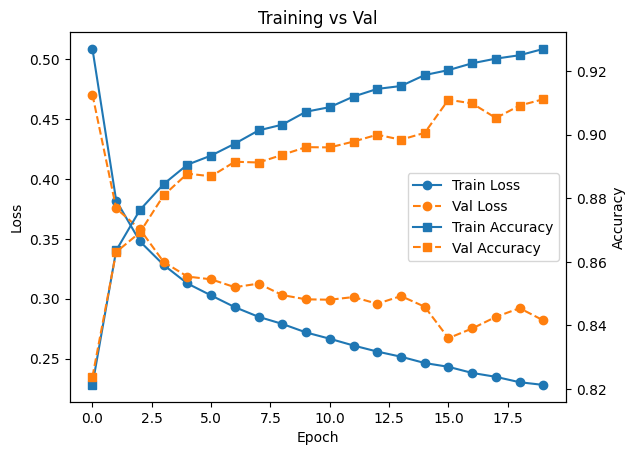

In [48]:
# 최적화 전 그래프 확인

fig, ax1 = plt.subplots()

# -----------------------
# Loss (왼쪽 y축)
# -----------------------
ax1.plot(history.history['loss'], label='Train Loss', linestyle='-', marker='o')
ax1.plot(history.history['val_loss'], label='Val Loss', linestyle='--', marker='o')

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# -----------------------
# Accuracy (오른쪽 y축)
# -----------------------
ax2 = ax1.twinx()

ax2.plot(history.history['accuracy'], label='Train Accuracy', linestyle='-', marker='s')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', linestyle='--', marker='s')

ax2.set_ylabel("Accuracy")

# -----------------------
# 범례 처리
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title("Training")
plt.show()

# < 훈련 결과 분석 >
# 훈련 세트의 경우 에포크가 늘어날수록 정확도와 로스율이 개선되지만...
# 검증 세트의 경우 에포크 15회 구간에서 정확도 및 로스율이 망가짐.

In [49]:
# 최적화 기법을 통해 로스율 낮추기!
model = model_fn()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',                 # 사용할 활성화 함수는 'adam'
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7783 - loss: 0.6426 - val_accuracy: 0.8591 - val_loss: 0.3970
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8601 - loss: 0.3940 - val_accuracy: 0.8718 - val_loss: 0.3481
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8732 - loss: 0.3487 - val_accuracy: 0.8801 - val_loss: 0.3254
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8821 - loss: 0.3219 - val_accuracy: 0.8857 - val_loss: 0.3080
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8877 - loss: 0.3019 - val_accuracy: 0.8876 - val_loss: 0.3014
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8936 - loss: 0.2863 - val_accuracy: 0.8907 - val_loss: 0.2863
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8971 - loss: 0.2719 - val_accuracy: 0.8935 - val_loss: 0.2753
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9028 - loss: 0.2591 -

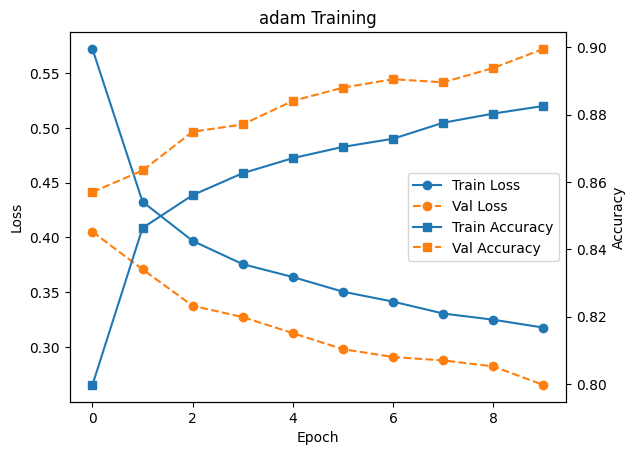

In [59]:
# 최적화 함수를 적용한 그래프 확인해보기

fig, ax1 = plt.subplots()

# -----------------------
# Loss (왼쪽 y축)
# -----------------------
ax1.plot(history.history['loss'], label='Train Loss', linestyle='-', marker='o')
ax1.plot(history.history['val_loss'], label='Val Loss', linestyle='--', marker='o')

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# -----------------------
# Accuracy (오른쪽 y축)
# -----------------------
ax2 = ax1.twinx()

ax2.plot(history.history['accuracy'], label='Train Accuracy', linestyle='-', marker='s')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', linestyle='--', marker='s')

ax2.set_ylabel("Accuracy")

# -----------------------
# 범례 처리
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title("adam Training")
plt.show()


# adam활성화 함수를 적용한 결과
# loss율이 확실하게 개선됨!

In [54]:
# 과대 적합을 막는 기술 ( 드롭아웃 )

# model_fn 함수에 드롭아웃 객체를 전달하여 층을 하나 더 추가하기
model = model_fn(keras.layers.Dropout(0.3)) # 30% 정도 드롭 아웃

model.summary() # 요약 확인

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# 드롭 아웃 복원하기
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=10, verbose=1,
                    validation_data=(val_scaled, val_target))
model.summary()

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7430 - loss: 0.7486 - val_accuracy: 0.8570 - val_loss: 0.4052
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8433 - loss: 0.4468 - val_accuracy: 0.8634 - val_loss: 0.3709
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8552 - loss: 0.4049 - val_accuracy: 0.8749 - val_loss: 0.3376
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8617 - loss: 0.3795 - val_accuracy: 0.8771 - val_loss: 0.3273
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8659 - loss: 0.3691 - val_accuracy: 0.8841 - val_loss: 0.3127
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8698 - loss: 0.3541 - val_accuracy: 0.8880 - val_loss: 0.2980
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8717 - loss: 0.3419 - val_accuracy: 0.8905 - val_loss: 0.2909
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8768 - loss: 0.3323 -

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_16 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [58]:
# 모델 저장하기
model.save('AI_exam.keras')

In [57]:
# HDF5 형식으로도 저장하기 ( 가중치 )
model.save_weights('AImodel-ep10.weights.h5')